## Regression and Model Comparison


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Load regression dataset


In [2]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(X.head())


X shape: (442, 10)
y shape: (442,)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


Train multiple regression models


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'DecisionTree': DecisionTreeRegressor(random_state=42, max_depth=5),
}

results = []
pred_store = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred_store[name] = pred
    results.append(
        {
            'Model': name,
            'MAE': mean_absolute_error(y_test, pred),
            'MSE': mean_squared_error(y_test, pred),
            'R2': r2_score(y_test, pred),
        }
    )

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df)


              Model        MAE          MSE        R2
0  LinearRegression  42.794095  2900.193628  0.452603
1             Ridge  46.138858  3077.415939  0.419153
2      DecisionTree  45.936955  3526.015512  0.334482


Visual compare actual vs predicted


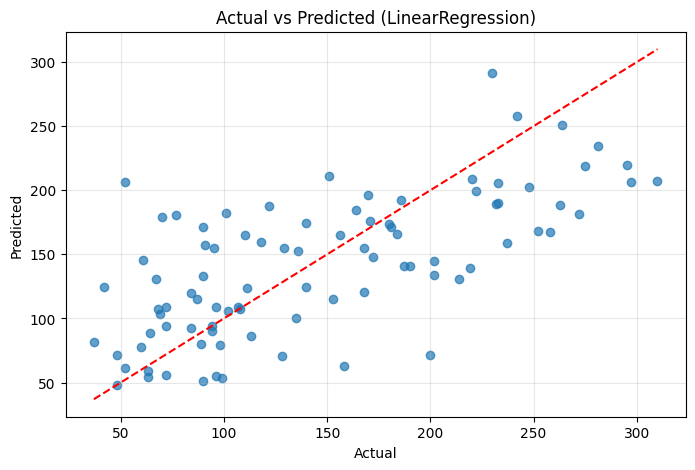

In [4]:
best_model_name = results_df.iloc[0]['Model']
best_pred = pred_store[best_model_name]

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True, alpha=0.3)
plt.show()
